In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import os
path_file = r"C:\Users\May Tinh Dung Hung\OneDrive\Desktop\cleandata\raw_data\Credit Risk Dataset.xlsx"

df = pd.read_excel(path_file)

In [47]:
# Kiểu dữ liệu + thông tin tổng quan
print("\nKiểu dữ liệu")
df.info()

print("\nTỷ lệ null")

null_percent = df.isnull().mean() * 100

# chỉ lấy cột có null > 0
null_percent = null_percent[null_percent > 0]

print(null_percent.sort_values(ascending=False))


Kiểu dữ liệu
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   client_ID                   32581 non-null  object 
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_status                 32581 non-null  int64  
 10  loan_percent_income         32581 non-null  float64
 11  cb_person_default_on_file   32581 non-null  object 
 12  cb_person_cred_hist_length  32581 non-null  int64  
 13  gender           

In [ ]:
duplicate_count = df.duplicated().sum()
print("Số dòng bị trùng:", duplicate_count)

Số dòng bị trùng: 0


In [48]:
for col in df.columns:
    print(f"\n===== {col} =====")
    
    if df[col].dtype == "object":
        print("Top values:")
        print(df[col].value_counts(dropna=False).head(5))
    else:
        print("Stats:")
        print(df[col].describe())


===== client_ID =====
Top values:
client_ID
CUST_32581    1
CUST_00001    1
CUST_00002    1
CUST_00003    1
CUST_00004    1
Name: count, dtype: int64

===== person_age =====
Stats:
count    32581.000000
mean        27.734600
std          6.348078
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max        144.000000
Name: person_age, dtype: float64

===== person_income =====
Stats:
count    3.258100e+04
mean     6.607485e+04
std      6.198312e+04
min      4.000000e+03
25%      3.850000e+04
50%      5.500000e+04
75%      7.920000e+04
max      6.000000e+06
Name: person_income, dtype: float64

===== person_home_ownership =====
Top values:
person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64

===== person_emp_length =====
Stats:
count    31686.000000
mean         4.789686
std          4.142630
min          0.000000
25%          2.000000
50%          4.000000
75%          7.000000
max 

Top các yếu tố dẫn đến vỡ nợ (Tương quan dương):
loan_status                    1.000000
loan_to_income_ratio           0.385873
loan_percent_income            0.379366
debt_to_income_ratio           0.321503
loan_int_rate                  0.319360
loan_grade_D                   0.318998
person_home_ownership_RENT     0.238430
loan_grade_E                   0.180122
cb_person_default_on_file_Y    0.179141
loan_amnt                      0.105376
loan_grade_F                   0.101841
Name: loan_status, dtype: float64


<Figure size 1200x1000 with 0 Axes>

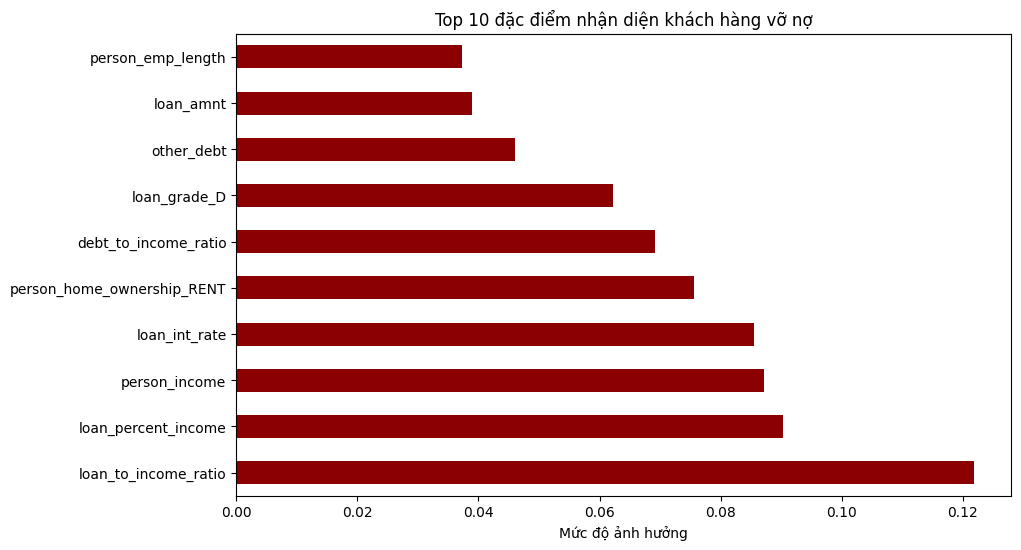

In [ ]:
# Tiền xử lý dữ liệu (Data Preprocessing)
# Loại bỏ các cột định danh và địa lý quá chi tiết (không giúp ích cho dự báo chung)
drop_cols = ['client_ID', 'city', 'state', 'country', 'city_latitude', 'city_longitude']
df_clean = df.drop(columns=drop_cols)

# Xử lý giá trị thiếu (nếu có) - Điền bằng giá trị trung bình 
df_clean['person_emp_length'] = df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median())
df_clean['loan_int_rate'] = df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median())

# 3. Mã hóa dữ liệu (Encoding)
# Chuyển các cột dạng chữ (Object) sang dạng số (Dummies)
df_ml = pd.get_dummies(df_clean, drop_first=True)

# 4. Phân tích tương quan (Correlation)
plt.figure(figsize=(12, 10))
# Lấy top 10 biến có tương quan mạnh nhất với loan_status
top_corr = df_ml.corr()['loan_status'].sort_values(ascending=False).head(11)
print("Top các yếu tố dẫn đến vỡ nợ (Tương quan dương):")
print(top_corr)

# 5. Tìm "Feature Importance" bằng Random Forest
# Chia X (đặc trưng) và y (mục tiêu)
X = df_ml.drop('loan_status', axis=1)
y = df_ml['loan_status']

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Trực quan hóa mức độ quan trọng của các cột
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='darkred')
plt.title('Top 10 đặc điểm nhận diện khách hàng vỡ nợ')
plt.xlabel('Mức độ ảnh hưởng')
plt.show()

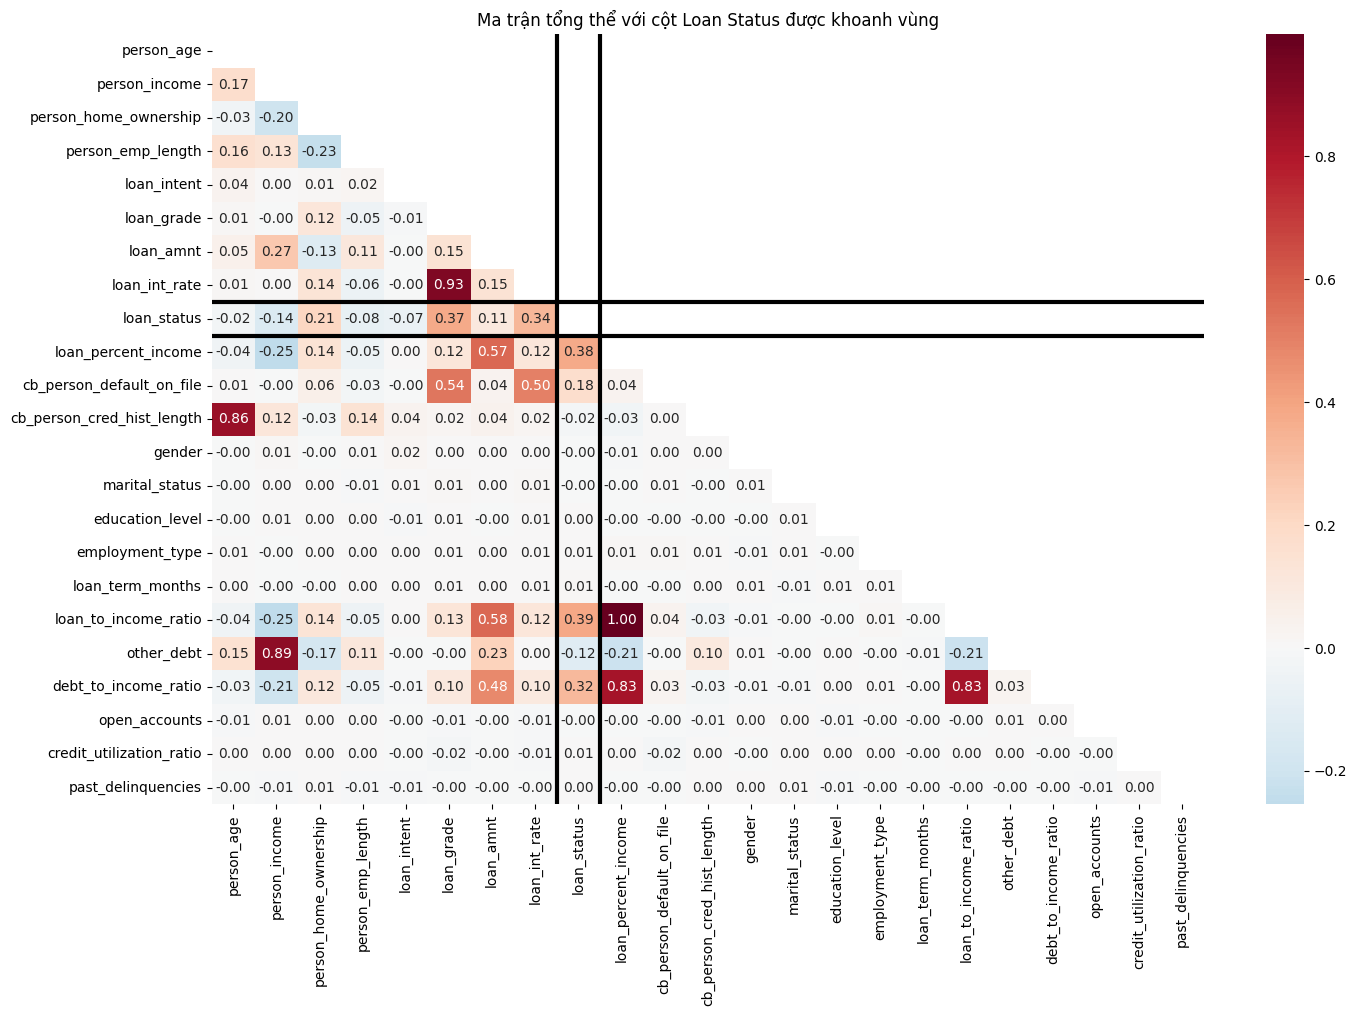

--- Tương quan trực tiếp với loan_status (Vỡ nợ) ---
loan_status                   1.000000
loan_to_income_ratio          0.385873
loan_percent_income           0.379366
loan_grade                    0.373080
loan_int_rate                 0.335133
debt_to_income_ratio          0.321503
person_home_ownership         0.211600
cb_person_default_on_file     0.179141
loan_amnt                     0.105376
loan_term_months              0.011820
employment_type               0.008949
credit_utilization_ratio      0.007289
education_level               0.004302
past_delinquencies            0.000465
gender                       -0.001273
marital_status               -0.002344
open_accounts                -0.002742
cb_person_cred_hist_length   -0.015529
person_age                   -0.021629
loan_intent                  -0.065575
person_emp_length            -0.082489
other_debt                   -0.118328
person_income                -0.144449
Name: loan_status, dtype: float64


In [ ]:
# Loại bỏ các cột định danh không có giá trị tính toán (ID, Tọa độ)
# Giữ lại các cột đặc trưng quan trọng
cols_to_drop = ['client_ID', 'city_latitude', 'city_longitude', 'city', 'state', 'country']
df_analysis = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

#  Chuyển đổi các cột dạng chữ (Object) sang dạng số để tính tương quan
# Dùng Label Encoding cho các cột có thứ bậc (như loan_grade) 
# và One-Hot Encoding cho các cột khác.
df_numeric = df_analysis.copy()

for col in df_numeric.select_dtypes(include=['object']).columns:
    df_numeric[col] = df_numeric[col].astype('category').cat.codes

# 4. Tính ma trận tương quan
corr_matrix = df_numeric.corr()

# 5. Trực quan hóa bằng Heatmap
plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Vẽ heatmap tổng thể
ax = sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', center=0)

# Tìm vị trí index của cột loan_status để vẽ khung
idx = corr_matrix.columns.get_loc('loan_status')

# Vẽ một đường viền nổi bật xung quanh cột loan_status
plt.axvline(x=idx, color='black', linewidth=3) # Đường dọc
plt.axvline(x=idx+1, color='black', linewidth=3)
plt.axhline(y=idx, color='black', linewidth=3) # Đường ngang
plt.axhline(y=idx+1, color='black', linewidth=3)

plt.title('Ma trận tổng thể với cột Loan Status được khoanh vùng')
plt.show()
#In ra Top các biến ảnh hưởng mạnh nhất tới 'loan_status'

print("--- Tương quan trực tiếp với loan_status (Vỡ nợ) ---")

print(corr_matrix['loan_status'].sort_values(ascending=False))

In [56]:
# Xuất file
# lấy tên file (không có đường dẫn)
filename = os.path.basename(path_file)

# tách tên và đuôi
name, _ = os.path.splitext(filename)

# tạo tên mới
new_filename = f"{name}_clean.csv"

# lấy thư mục hiện tại của file gốc
folder = os.path.dirname(path_file)

# thay raw_data → clean_data
output_folder = folder.replace("raw_data", "clean_data")

# tạo full path output
output_path = os.path.join(output_folder, new_filename)

# 4. Lưu file
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print("Saved to:", output_path)

Saved to: C:\Users\May Tinh Dung Hung\OneDrive\Desktop\cleandata\clean_data\Credit Risk Dataset_clean.csv
